# Week 11 - Combining Models

Learning contents:
- Base Classifier
    - Train a Least Squares classifier, perform a prediction on the samples, and compute the accuracy
    - Plot the decision boundary for least squares classifier
- Committees
    - Split the training data into M=9 equally sized, non-overlapping parts
    - Train M=9 Least Squares classifiers, one for each data split
    - Perform predictions on the whole dataset using a comitteee of classifiers and compute the accuracy
    - Plot the decision boundary for committee classifier
- Decision tree
    - Fit a DecisionTreeClassifier using scikit-learn, perform a prediction on the data, and compute the accuracy
    - Plot the decision boundary for the DecisionTreeClassifier
- AdaBoost
    - Create an AdaBoost classifier of DecisionTreeClassifiers using the scikit-learn library
    - Plot the decision boundary for the AdaBoostClassifier


In [87]:
# Dependencies
import numpy as np
from sklearn import tree
import scipy
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA 
import matplotlib.pyplot as plt 
import seaborn as sns; sns.set(); sns.set_palette('bright')

In [9]:
# Some plotting functions, we'll be using later


def plot_scatter(data, target, alpha=0.5, legend=True):
    scatter = plt.scatter(data[:, 0], data[:, 1], c=target, edgecolor='none', alpha=alpha, cmap='rainbow')
    if legend:
        plt.legend(*scatter.legend_elements(), loc="upper right", title="Targets")
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    
def plot_mesh(X, pred_fn, n_class=2):
    plt_margin = 5
    x_min, x_max = min(X[:,0]) - plt_margin, max(X[:,0]) + plt_margin
    y_min, y_max = min(X[:,1]) - plt_margin, max(X[:,1]) + plt_margin
    h = 0.1  # step size in the mesh
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = pred_fn(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, alpha = 0.1, cmap=plt.cm.get_cmap('rainbow', n_class))




# Dataset
We'll be working with a slightly modified version of the digits data

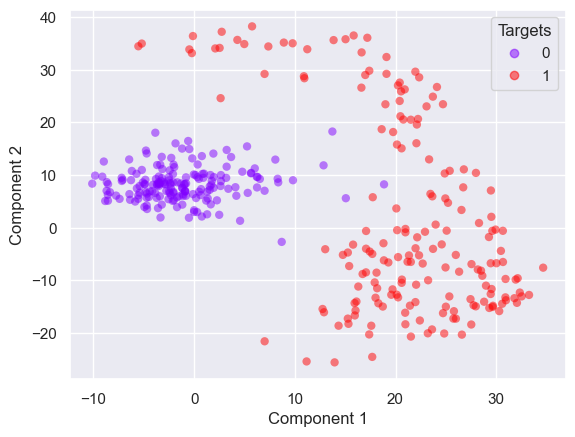

In [3]:
digits = load_digits(n_class=2)

# Get a 2D version of the data using PCA
pca = PCA(n_components=2)
t = digits.target
X = pca.fit_transform(digits.data)

# In order to get a non-linearly seperable case, 
# we'll modify the data a bit this time, 
# translating the '-1' class to the right and up
X = np.where(
    np.repeat(np.expand_dims(t == 1, axis=1), 2, axis=1), 
    X, 
    np.vstack([X[:,0]+20, X[:,1]+10]).T
)

N = len(t) # total number of samples

plot_scatter(X, t)

# 0) Base Classifier

## 0.1) Train a Least Squares classifier, perform a prediction on the samples, and compute the accuracy
Use your solution from the exercise "Week 7 - Linear classification" section 1.1 and 1.2. The accuracy is to be calculated in terms of the proportion of correct predictions compared to the number of predictions and should print a single float.

In [58]:
x_tilda = np.hstack([np.ones((X.shape[0], 1)), X])
x_pseudo_inv = np.linalg.pinv(x_tilda.T @ x_tilda) @ x_tilda.T
w_tilda = np.array(x_pseudo_inv @ t)

def predict(x_tilda,w_tilda , boundary = 0.5):    
    y = x_tilda @ w_tilda.T
    pred = np.array([1 if x > boundary else 0 for x in y])
    return pred 

def PHI(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

def accuracy(predictions, targets):
    correct = np.sum(predictions == targets)
    total = targets.shape[0]
    return correct / total

predictions = predict(w_tilda, x_tilda)

acc = accuracy(predictions, t)
acc



0.9472222222222222

## 0.2) Plot the decision boundary for least squares classifier
Hint: you can do this by either plotting a line on the boundary or creating a mesh of all predictions (simmilar to section 1.3 in "week 7 - Linear classification").

/var/folders/65/1n30j6qx5qg79xwsb8vr4v1c0000gn/T/ipykernel_19631/3329743522.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cs = plt.contourf(xx, yy, Z, alpha = 0.1, cmap=plt.cm.get_cmap('rainbow', n_class))


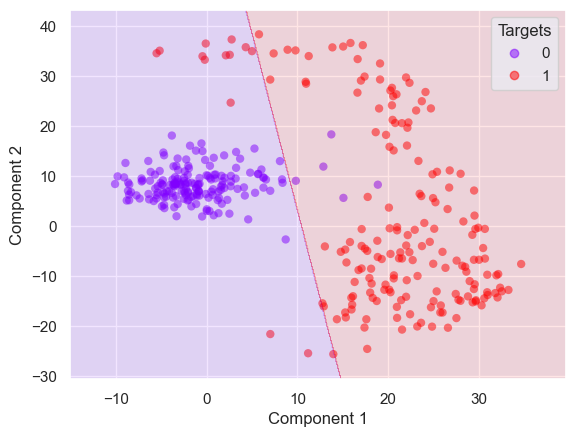

In [42]:
def plot_decision_boundary(data, weights):
    weights = weights.flatten()
    x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
    xx = np.linspace(x_min, x_max)
    yy = (-weights[1] * xx - weights[0]) / weights[2]
    
    plt.plot(xx, yy, 'k--')
    plt.xlim(x_min, x_max)
    plt.ylim(data[:, 1].min() - 1, data[:, 1].max() + 1)





plot_scatter(X, t)
plot_mesh(X, lambda x: predict(w_tilda, PHI(x), 0.5), n_class=2)


# 1) Committees

## 1.1) Split the training data into M=9 equally sized, non-overlapping parts
Hint: use the numpy.split() command.

In [76]:
M = 9

data_split = np.split(X, M)
t_split = np.split(t, M)


## 1.2) Train M=9 Least Squares classifiers, one for each (9) data split using the same method as in section 0.1
Hint: loop over the training data containing of the X split and t split zipped together using the zip() command.

In [77]:
weights = []
for x_part, t_part in zip(data_split, t_split):

    x_tilda = np.hstack([np.ones((x_part.shape[0], 1)), x_part])
    x_pseudo_inv = np.linalg.pinv(x_tilda.T @ x_tilda) @ x_tilda.T
    w_tilda_part = np.array(x_pseudo_inv @ t_part)

    weights.append(w_tilda_part)
print(weights[0].shape)

(3,)


## 1.3) Perform a prediction on the whole dataset using committee of classifiers (lecture 17 slide 4) and compute the accuracy 

In [78]:
def committee_predict(x_tilda, weights):

    all_predictions = [predict(x_tilda, w) for w in weights]
    
    sum_predictions = np.sum(all_predictions, axis=0)
    
    # Using majority voting
    committee_predictions = np.where(sum_predictions > len(weights) / 2, 1, 0)

    return committee_predictions

x_tilda = np.hstack([np.ones((X.shape[0], 1)), X])
committee_predictions = committee_predict(x_tilda, weights)

acc_committee = accuracy(committee_predictions, t)
acc_committee


0.9444444444444444

## 1.4 Plot the decision boundary for committee classifier

/var/folders/65/1n30j6qx5qg79xwsb8vr4v1c0000gn/T/ipykernel_19631/3329743522.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cs = plt.contourf(xx, yy, Z, alpha = 0.1, cmap=plt.cm.get_cmap('rainbow', n_class))


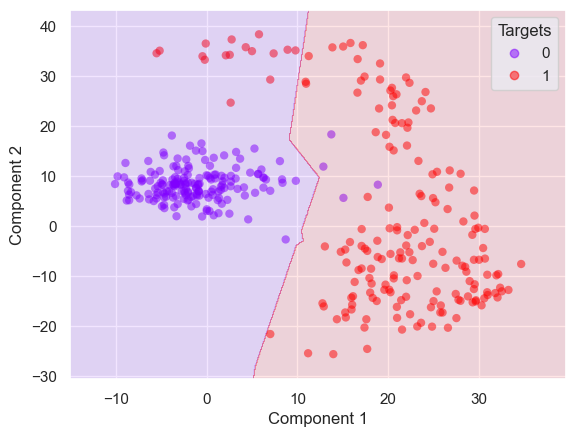

In [95]:

plot_scatter(X, t)
#plot_mesh(X, lambda x: committee_predict(x_part, weights), n_class=2)
plot_mesh(X, lambda x: committee_predict(np.hstack([np.ones((x.shape[0], 1)), x]), weights), n_class=2)
